#### 과일 Data를 CNN으로 이미지 분류

In [1]:
a=1

In [73]:
import numpy as np
fruits = np.load('data/fruits.npy')
fruits.shape # 사과, 파인애플, 바나나

(300, 100, 100)

In [74]:
# Target 만들기
target = np.concatenate(
    [
        np.zeros(100),
        np.ones(100),
        np.ones(100)*2
    ]
)
target.shape

(300,)

In [ ]:
train = fruits.reshape(-1, 100, 100, 1) / 255.0

#### train과 test

In [76]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(240, 100, 100, 1) (240,)
(60, 100, 100, 1) (60,)


#### CNN 만들기

In [ ]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu',padding='same', input_shape=(100, 100, 1)))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu',padding='same'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu',padding='same'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dropout(0.5))  # 과적합 방지용 (선택)
model.add(keras.layers.Dense(10, activation='softmax')) # 이진분류만 SIGMOID

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,858 (2.60 MB)

 Trainable params: 682,858 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('data/best_CNN_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
) 

history= model.fit(
    train_input,
    train_target,
    epochs=20,
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4500 - loss: 1.5479
Epoch 2/20
2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6719 - loss: 0.9032

/opt/anaconda3/envs/deep_env/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7292 - loss: 0.6985
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8708 - loss: 0.3565
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9458 - loss: 0.1944
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9417 - loss: 0.1457
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9417 - loss: 0.1290
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9625 - loss: 0.1068
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9667 - loss: 0.0982
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9750 - loss: 0.0782
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9667 - loss: 0.0997
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9458 - loss: 0.1481
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9583 - loss: 0.0920
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9417 - loss: 0.1199
Epoch 14/20

In [82]:
model = keras.models.load_model('data/best_CNN_model.keras')
model.evaluate(test_input, test_target)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 3.0787e-04 


[0.0003078693407587707, 1.0]

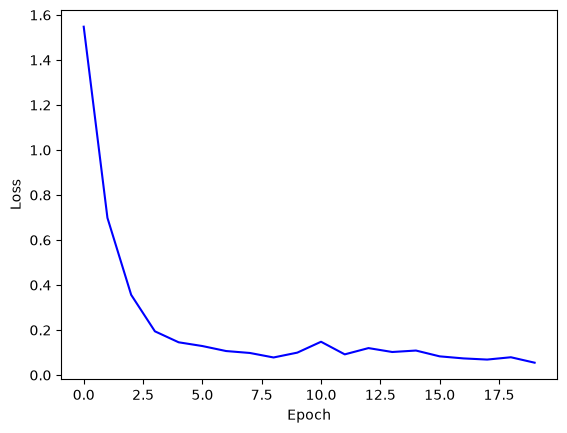

In [ ]:
import matplotlib.pyplot as plt
# history의 시각화
plt.plot(history.history['loss'], color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()